<a href="https://colab.research.google.com/github/sashachereshnya-pixel/compling2025/blob/main/%D0%A7%D0%95%D0%A0%D0%95%D0%92%D0%98%D0%9A_%D0%A1%D0%95%D0%9C%D0%98%D0%9D%D0%90%D0%A0_convnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практический семинар: CNN для Fashion-MNIST

1.  Подготовка данных
2.  Архитектура "учителя" (образец)
3.  **Ваша модель** (практика)
4.  Обучение и оценка
5.  Эксперимент


## Часть 1: загрузка и подготовка данных

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# 1. Загрузка Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# 2. Нормализация (делим на 255)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Преобразуем метки в one-hot encoding (готовый код)
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# 4. Добавляем размерность канала (для Conv2D)
x_train = np.expand_dims(x_train, axis=-1)  # (60000,28,28,1)
x_test = np.expand_dims(x_test, axis=-1)    # (10000,28,28,1)

print(f"x_train shape: {x_train.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")

# Словарь классов
class_names = ['Футболка', 'Брюки', 'Свитер', 'Платье', 'Пальто',
               'Сандаль', 'Рубашка', 'Кроссовок', 'Сумка', 'Ботильон']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28, 1)
y_train_cat shape: (60000, 10)


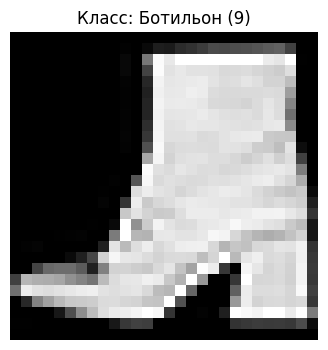

Индекс: 41033
Размер изображения: (28, 28, 1)
Метка (число): 9
Метка (текст): Ботильон


In [2]:
# Визуализация случайного изображения
import random

# Случайный индекс
idx = random.randint(0, len(x_train) - 1)

# Получаем изображение и метку
image = x_train[idx]
label = y_train[idx]

# Создаем график
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap='gray')  # Убираем размерность канала для отображения
plt.title(f"Класс: {class_names[label]} ({label})")
plt.axis('off')
plt.show()

# Дополнительная информация
print(f"Индекс: {idx}")
print(f"Размер изображения: {image.shape}")
print(f"Метка (число): {label}")
print(f"Метка (текст): {class_names[label]}")

## Часть 2: архитектура 'Учителя' (образец)

In [3]:
# Модель 'Учитель'
teacher_model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

teacher_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Вопросы для понимания (обсудите в группе или ответьте письменно):
1.  **Flatten:** Зачем нужен этот слой? Что он делает с данными?
Слой Flatten преобразует многомерные данные в одномерный вектор.

Что происходит:

На входе у Flatten: тензор формы (batch_size, height, width, channels)

На выходе: вектор формы (batch_size, height * width * channels)

Пример из кода:
После сверточных и пулинговых слоев данные имеют форму примерно (batch_size, 5, 5, 64).
Flatten преобразует это в (batch_size, 5 * 5 * 64) = (batch_size, 1600).

Зачем это нужно:
Полносвязные слои (Dense) работают только с одномерными данными. Flatten "распрямляет" многомерные карты признаков в вектор, который можно подать на Dense-слои.

2.  **MaxPooling2D:** Какую функцию выполняет? Почему он следует за Conv2D?
Основные функции MaxPooling2D:

Уменьшение размерности (subsampling):

Уменьшает высоту и ширину карты признаков (обычно в 2 раза при pool_size=(2,2))

Пример: (26, 26, 32) → (13, 13, 32)

Увеличение инвариантности:

Делает сеть менее чувствительной к небольшим сдвигам/искажениям объектов

Выделяет наиболее важные признаки (беря максимум в окне)

Снижение вычислительной сложности:

Меньше параметров для последующих слоев

Быстрее обучение и inference

Почему следует за Conv2D:
Типичный паттерн: Conv → Pool → Conv → Pool

Conv2D: извлекает локальные признаки (грани, текстуры)

MaxPooling2D: уменьшает размерность, усиливает важные признаки

Это позволяет сети видеть "более крупные" паттерны на следующих слоях



3.  **Последний Dense слой:** Почему в нём 10 нейронов и активация `softmax`?
10 нейронов:
Количество нейронов равно количеству классов в Fashion-MNIST:

Футболка (0), Брюки (1), Свитер (2), Платье (3), Пальто (4)

Сандаль (5), Рубашка (6), Кроссовок (7), Сумка (8), Ботильон (9)

Каждый нейрон отвечает за вероятность принадлежности к одному из классов.

Активация softmax:

Преобразует выходы нейронов в вероятностное распределение

Гарантирует, что сумма выходов всех нейронов = 1

Каждое значение ∈ [0, 1]
---

## Часть 3: ваша модель (практика сборки)

**Задание:** соберите CNN **точно по этой спецификации**:
1.  Conv2D: 16 фильтров, размер 3x3, активация `relu`, `input_shape=(28,28,1)`
2.  MaxPooling2D: пул 2x2
3.  Conv2D: 32 фильтра, 3x3, `relu`
4.  MaxPooling2D: 2x2
5.  Flatten
6.  Dense: 64 нейрона, `relu`
7.  Dense: 10 нейронов, `softmax`

**Заполните пропуски ниже**

In [4]:
# Ваша модель (студент)
student_model = keras.Sequential([
    # Слой 1: Conv2D (16 фильтров, 3x3, relu, правильный input_shape)
    keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # Слой 2: MaxPooling2D (2,2)
    keras.layers.MaxPooling2D((2, 2)),

    # Слой 3: Conv2D (32 фильтра, 3x3, relu)
    keras.layers.Conv2D(32, (3, 3), activation='relu'),

    # Слой 4: MaxPooling2D (2,2)
    keras.layers.MaxPooling2D((2, 2)),

    # Слой 5: Flatten
    keras.layers.Flatten(),

    # Слой 6: Dense (64 нейрона, relu)
    keras.layers.Dense(64, activation='relu'),

    # Слой 7: Dense (10 нейронов, softmax)
    keras.layers.Dense(10, activation='softmax')
])

student_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

---

## Часть 4: компиляция и обучение

In [5]:
# Учитель: компиляция
teacher_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [6]:
# Учитель: обучение (5 эпох)
teacher_history = teacher_model.fit(x_train, y_train,  # Используем исходные метки (не one-hot)
                                    epochs=5,
                                    validation_split=0.2,
                                    verbose=1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - accuracy: 0.7655 - loss: 0.6547 - val_accuracy: 0.8788 - val_loss: 0.3449
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.8823 - loss: 0.3234 - val_accuracy: 0.8879 - val_loss: 0.3047
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.9043 - loss: 0.2670 - val_accuracy: 0.8880 - val_loss: 0.3006
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9153 - loss: 0.2309 - val_accuracy: 0.9059 - val_loss: 0.2571
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.9252 - loss: 0.1986 - val_accuracy: 0.9100 - val_loss: 0.2543


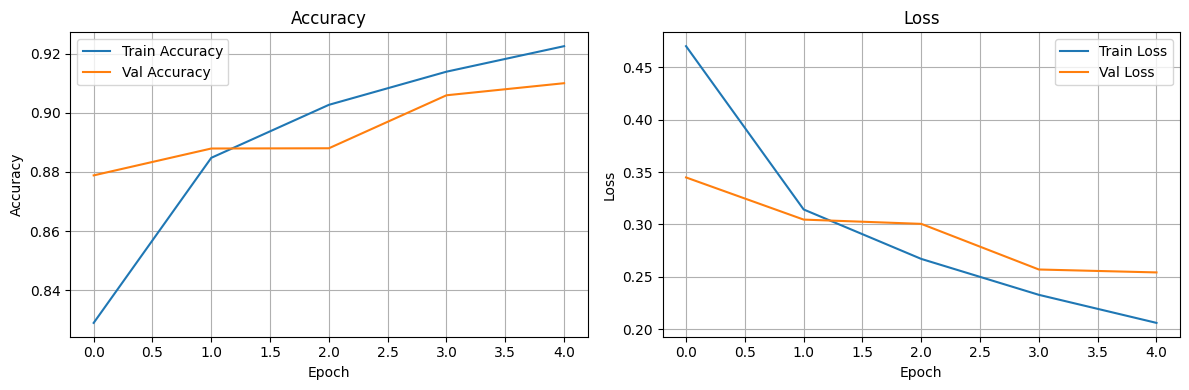

In [7]:
# Визуализация процесса обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# График точности
axes[0].plot(teacher_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(teacher_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# График потерь
axes[1].plot(teacher_history.history['loss'], label='Train Loss')
axes[1].plot(teacher_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Задание:**
1.  Скомпилируйте `student_model` с оптимизатором **`sgd`**
2.  Добавьте метрику **`'sparse_top_k_categorical_accuracy'`** к списку метрик
3.  Обучите модель на **3 эпохи** с `validation_split=0.2`
4.  Постройте график обучения

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.8306 - loss: 0.4587 - sparse_top_k_categorical_accuracy: 0.9974 - val_accuracy: 0.8411 - val_loss: 0.4459 - val_sparse_top_k_categorical_accuracy: 0.9961
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.8456 - loss: 0.4272 - sparse_top_k_categorical_accuracy: 0.9968 - val_accuracy: 0.8414 - val_loss: 0.4332 - val_sparse_top_k_categorical_accuracy: 0.9967
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8526 - loss: 0.4086 - sparse_top_k_categorical_accuracy: 0.9972 - val_accuracy: 0.8547 - val_loss: 0.4067 - val_sparse_top_k_categorical_accuracy: 0.9967


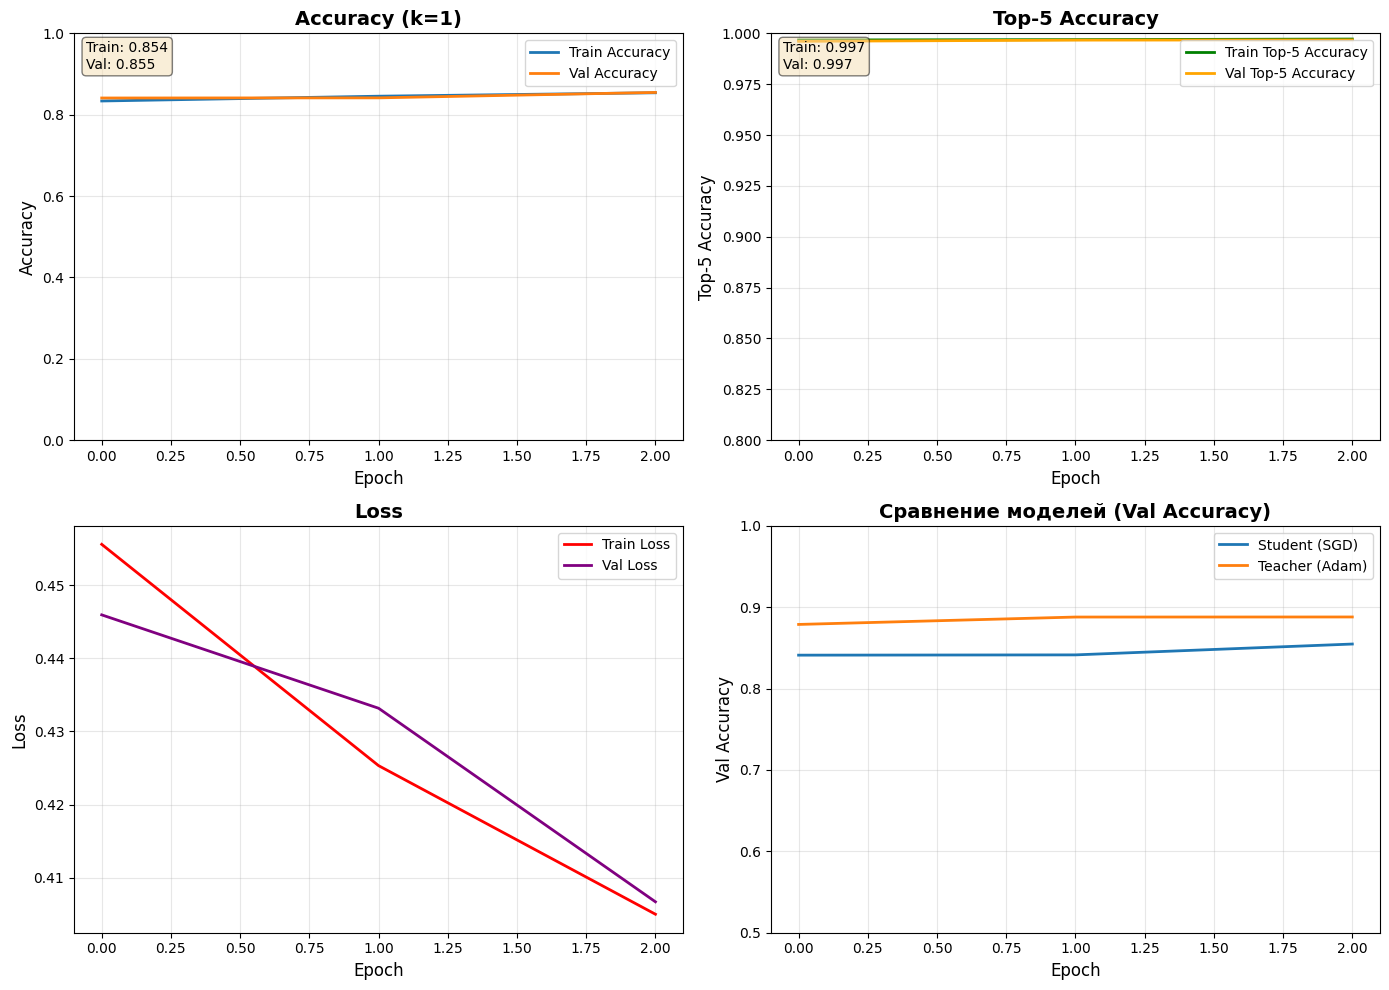

In [10]:
# 1. Компиляция вашей модели (sgd, sparse_categorical_crossentropy, accuracy + sparse_top_k_categorical_accuracy)
student_model.compile(
    optimizer='sgd',  # Используем SGD вместо Adam
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', 'sparse_top_k_categorical_accuracy']  # Добавляем top-k метрику
)

# 2. Обучение (3 эпохи, validation_split=0.2)
student_history = student_model.fit(
    x_train,
    y_train,  # Используем исходные метки (целые числа)
    epochs=3,
    validation_split=0.2,
    verbose=1
)

# 3. График обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Accuracy
axes[0, 0].plot(student_history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(student_history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 0].set_title('Accuracy (k=1)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# Добавим финальные значения в легенду
final_train_acc = student_history.history['accuracy'][-1]
final_val_acc = student_history.history['val_accuracy'][-1]
axes[0, 0].text(0.02, 0.98, f'Train: {final_train_acc:.3f}\nVal: {final_val_acc:.3f}',
                transform=axes[0, 0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# График 2: Top-k Accuracy (k=5)
axes[0, 1].plot(student_history.history['sparse_top_k_categorical_accuracy'],
                label='Train Top-5 Accuracy', linewidth=2, color='green')
axes[0, 1].plot(student_history.history['val_sparse_top_k_categorical_accuracy'],
                label='Val Top-5 Accuracy', linewidth=2, color='orange')
axes[0, 1].set_title('Top-5 Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Top-5 Accuracy', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.8, 1])

# Добавим финальные значения
final_train_topk = student_history.history['sparse_top_k_categorical_accuracy'][-1]
final_val_topk = student_history.history['val_sparse_top_k_categorical_accuracy'][-1]
axes[0, 1].text(0.02, 0.98, f'Train: {final_train_topk:.3f}\nVal: {final_val_topk:.3f}',
                transform=axes[0, 1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# График 3: Loss
axes[1, 0].plot(student_history.history['loss'], label='Train Loss', linewidth=2, color='red')
axes[1, 0].plot(student_history.history['val_loss'], label='Val Loss', linewidth=2, color='purple')
axes[1, 0].set_title('Loss', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: Сравнение моделей (если есть данные учителя)
try:
    axes[1, 1].plot(student_history.history['val_accuracy'], label='Student (SGD)', linewidth=2)
    axes[1, 1].plot(teacher_history.history['val_accuracy'][:3], label='Teacher (Adam)', linewidth=2)
    axes[1, 1].set_title('Сравнение моделей (Val Accuracy)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Val Accuracy', fontsize=12)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim([0.5, 1])
except NameError:
    # Если нет данных учителя, покажем только студенческую модель
    axes[1, 1].plot(student_history.history['val_accuracy'], label='Student (SGD)', linewidth=2)
    axes[1, 1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Val Accuracy', fontsize=12)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



---

## Часть 5: оценка и сравнение моделей

In [13]:
from sklearn.metrics import classification_report

# 1. Оценка точности на тесте
teacher_test_loss, teacher_test_acc = teacher_model.evaluate(x_test, y_test, verbose=0)
print(f"\nМодель 'Учитель' на тесте:")
print(f"  Loss:     {teacher_test_loss:.4f}")
print(f"  Accuracy: {teacher_test_acc:.4f}")

# 2. Подробный отчёт
y_pred_teacher = teacher_model.predict(x_test)
y_pred_classes_teacher = np.argmax(y_pred_teacher, axis=1)
print("\nОтчёт classification_report для учителя:")
print(classification_report(y_test, y_pred_classes_teacher, target_names=class_names))


Модель 'Учитель' на тесте:
  Loss:     0.2677
  Accuracy: 0.9023
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Отчёт classification_report для учителя:
              precision    recall  f1-score   support

    Футболка       0.85      0.84      0.85      1000
       Брюки       0.99      0.98      0.98      1000
      Свитер       0.82      0.88      0.85      1000
      Платье       0.93      0.88      0.91      1000
      Пальто       0.85      0.84      0.85      1000
     Сандаль       0.99      0.97      0.98      1000
     Рубашка       0.74      0.71      0.72      1000
   Кроссовок       0.94      0.97      0.96      1000
       Сумка       0.94      0.98      0.96      1000
    Ботильон       0.97      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



**Задание:**
1.  Оцените вашу модель (`student_model`) на тестовых данных. Получите `loss` и `accuracy`.
2.  Сравните accuracy с моделью учителя. Какая лучше и почему (возможные причины)?
3.  Выведите `classification_report` для вашей модели.


In [18]:
# 1. Оценка точности вашей модели на тесте
# Метод evaluate возвращает все метрики, которые мы указали при компиляции
# Порядок: [loss, accuracy, sparse_top_k_categorical_accuracy]
evaluation_results = student_model.evaluate(x_test, y_test, verbose=0)

# Распаковываем результаты
student_test_loss = evaluation_results[0]
student_test_acc = evaluation_results[1]  # Обычная accuracy

# 2. Сравнение
print(f"\nСравнение точности на тесте:")
print(f"  Учитель (adam):  {teacher_test_acc:.4f}")
print(f"  Ваша модель (sgd): {student_test_acc:.4f}")


# Анализ сравнения
accuracy_difference = teacher_test_acc - student_test_acc
if accuracy_difference > 0.01:
    print(f"\n✓ Модель учителя лучше на {accuracy_difference:.4f} ({(accuracy_difference*100):.1f}%)")
elif accuracy_difference < -0.01:
    print(f"\n✓ Ваша модель лучше на {abs(accuracy_difference):.4f} ({(abs(accuracy_difference)*100):.1f}%)")
else:
    print(f"\n✓ Модели показали сопоставимые результаты (разница: {accuracy_difference:.4f})")

# 3. Отчёт classification_report для вашей модели
y_pred_student = student_model.predict(x_test, verbose=0)
y_pred_classes_student = np.argmax(y_pred_student, axis=1)

print(f"\n{'='*80}")
print("CLASSIFICATION REPORT - ВАША МОДЕЛЬ (STUDENT)")
print(f"{'='*80}")
print(classification_report(y_test, y_pred_classes_student,
                           target_names=class_names, digits=3))



Сравнение точности на тесте:
  Учитель (adam):  0.9023
  Ваша модель (sgd): 0.8513

✓ Модель учителя лучше на 0.0510 (5.1%)

CLASSIFICATION REPORT - ВАША МОДЕЛЬ (STUDENT)
              precision    recall  f1-score   support

    Футболка      0.821     0.788     0.804      1000
       Брюки      0.993     0.954     0.973      1000
      Свитер      0.749     0.789     0.768      1000
      Платье      0.766     0.931     0.841      1000
      Пальто      0.735     0.756     0.746      1000
     Сандаль      0.957     0.954     0.955      1000
     Рубашка      0.670     0.499     0.572      1000
   Кроссовок      0.928     0.923     0.925      1000
       Сумка      0.939     0.964     0.951      1000
    Ботильон      0.938     0.955     0.946      1000

    accuracy                          0.851     10000
   macro avg      0.849     0.851     0.848     10000
weighted avg      0.849     0.851     0.848     10000



---

## Часть 6: эксперимент

**Задание:** модифицируйте вашу модель `student_model`, добавив слой **`Dropout(0.3)`** после первого `Dense`-слоя (с 64 нейронами). Переобучите модель на 3 эпохи. Как изменилась точность на валидации и тесте? Стала ли модель лучше обобщаться?

*Подсказка: используйте `keras.layers.Dropout(0.3)`.*


ЭКСПЕРИМЕНТ: ДОБАВЛЕНИЕ DROPOUT ДЛЯ УЛУЧШЕНИЯ ОБОБЩЕНИЯ


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Архитектура модели с Dropout:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)


ОБУЧЕНИЕ МОДЕЛИ С DROPOUT (3 ЭПОХИ)
Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4580 - loss: 1.5021 - sparse_top_k_categorical_accuracy: 0.8911 - val_accuracy: 0.7590 - val_loss: 0.6647 - val_sparse_top_k_categorical_accuracy: 0.9919
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.7276 - loss: 0.7279 - sparse_top_k_categorical_accuracy: 0.9897 - val_accuracy: 0.7883 - val_loss: 0.5644 - val_sparse_top_k_categorical_accuracy: 0.9952
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7705 - loss: 0.6134 - sparse_top_k_categorical_accuracy: 0.9937 - val_accuracy: 0.8107 - val_loss: 0.5000 - val_sparse_top_k_categorical_accuracy: 0.9960


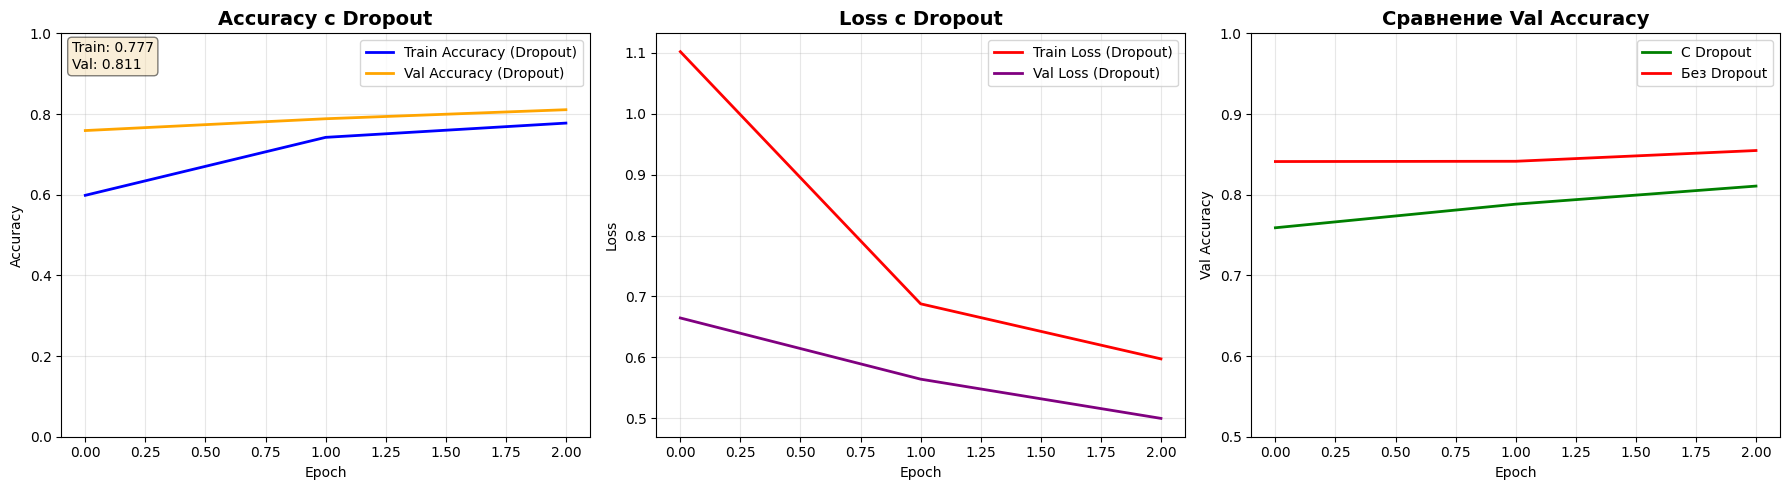


ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ

РЕЗУЛЬТАТЫ НА ТЕСТЕ:
------------------------------------------------------------
Метрика                   Без Dropout     С Dropout       Изменение      
------------------------------------------------------------
Test Loss                 0.4154          0.5191          +0.1036
Test Accuracy             0.8513          0.8029          -0.0484

АНАЛИЗ ОБОБЩАЮЩЕЙ СПОСОБНОСТИ

РАЗНИЦА МЕЖДУ TRAIN И VAL ACCURACY (показатель переобучения):
  Без Dropout: -0.0008
  С Dropout:   -0.0332

✓ Dropout уменьшил переобучение на 0.0324

ПОДРОБНЫЙ АНАЛИЗ ВЛИЯНИЯ DROPOUT

1. ЧТО ТАКОЕ DROPOUT (0.3)?
   - Во время обучения: случайным образом 'отключает' 30% нейронов
   - Во время инференса (предсказания): все нейроны активны
   - Эффект: предотвращает ко-адаптацию нейронов, заставляя сеть учить более robustные признаки

2. ОЖИДАЕМЫЕ ЭФФЕКТЫ:
   - Train accuracy: может быть ниже (медленнее обучение)
   - Val/Test accuracy: может быть выше (лучшее обобщение)
   - Разница 

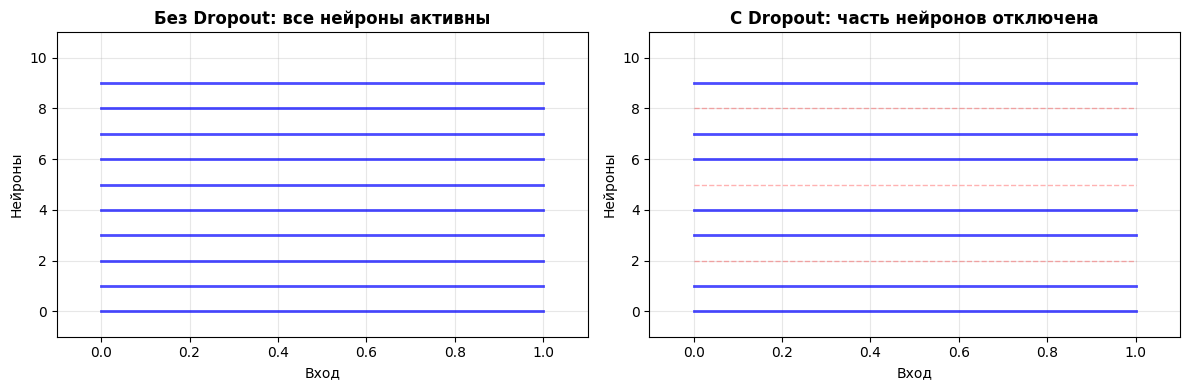


ИТОГОВЫЙ ВЫВОД ЭКСПЕРИМЕНТА
✗ DROPOUT УХУДШИЛ РЕЗУЛЬТАТЫ
  Уменьшение test accuracy: 4.84%

  Возможные причины:
  1. Dropout слишком агрессивный для этой архитектуры
  2. Модель слишком простая, dropout мешает обучению
  3. Недостаточно эпох для адаптации к dropout



In [19]:
# Часть 6: Эксперимент с Dropout

print("="*80)
print("ЭКСПЕРИМЕНТ: ДОБАВЛЕНИЕ DROPOUT ДЛЯ УЛУЧШЕНИЯ ОБОБЩЕНИЯ")
print("="*80)

# 1. Создаем новую модель с Dropout
student_model_dropout = keras.Sequential([
    # Слой 1: Conv2D (16 фильтров, 3x3, relu)
    keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # Слой 2: MaxPooling2D (2,2)
    keras.layers.MaxPooling2D((2, 2)),

    # Слой 3: Conv2D (32 фильтра, 3x3, relu)
    keras.layers.Conv2D(32, (3, 3), activation='relu'),

    # Слой 4: MaxPooling2D (2,2)
    keras.layers.MaxPooling2D((2, 2)),

    # Слой 5: Flatten
    keras.layers.Flatten(),

    # Слой 6: Dense (64 нейрона, relu)
    keras.layers.Dense(64, activation='relu'),

    # Слой 7: Dropout (30% - 0.3) - НОВЫЙ СЛОЙ
    keras.layers.Dropout(0.3),

    # Слой 8: Dense (10 нейронов, softmax)
    keras.layers.Dense(10, activation='softmax')
])

print("Архитектура модели с Dropout:")
student_model_dropout.summary()

# 2. Компиляция модели (те же параметры для сравнения)
student_model_dropout.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', 'sparse_top_k_categorical_accuracy']
)

# 3. Обучение модели на 3 эпохи
print("\n" + "="*80)
print("ОБУЧЕНИЕ МОДЕЛИ С DROPOUT (3 ЭПОХИ)")
print("="*80)

history_dropout = student_model_dropout.fit(
    x_train,
    y_train,
    epochs=3,
    validation_split=0.2,
    verbose=1
)

# 4. Визуализация обучения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Accuracy
axes[0].plot(history_dropout.history['accuracy'], label='Train Accuracy (Dropout)', linewidth=2, color='blue')
axes[0].plot(history_dropout.history['val_accuracy'], label='Val Accuracy (Dropout)', linewidth=2, color='orange')
axes[0].set_title('Accuracy с Dropout', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Добавляем аннотацию с финальными значениями
final_train_acc_dropout = history_dropout.history['accuracy'][-1]
final_val_acc_dropout = history_dropout.history['val_accuracy'][-1]
axes[0].text(0.02, 0.98, f'Train: {final_train_acc_dropout:.3f}\nVal: {final_val_acc_dropout:.3f}',
             transform=axes[0].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# График 2: Loss
axes[1].plot(history_dropout.history['loss'], label='Train Loss (Dropout)', linewidth=2, color='red')
axes[1].plot(history_dropout.history['val_loss'], label='Val Loss (Dropout)', linewidth=2, color='purple')
axes[1].set_title('Loss с Dropout', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: Сравнение с моделью без Dropout
axes[2].plot(history_dropout.history['val_accuracy'], label='С Dropout', linewidth=2, color='green')
try:
    axes[2].plot(student_history.history['val_accuracy'], label='Без Dropout', linewidth=2, color='red')
except:
    # Если student_history не определена, переобучим модель без dropout для сравнения
    print("\nПереобучение модели без Dropout для сравнения...")
    student_model_no_dropout = keras.Sequential([
        keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(32, (3, 3), activation='relu'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    student_model_no_dropout.compile(
        optimizer='sgd',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history_no_dropout = student_model_no_dropout.fit(
        x_train, y_train,
        epochs=3,
        validation_split=0.2,
        verbose=0
    )
    axes[2].plot(history_no_dropout.history['val_accuracy'], label='Без Dropout', linewidth=2, color='red')
    student_history = history_no_dropout

axes[2].set_title('Сравнение Val Accuracy', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Val Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0.5, 1])

plt.tight_layout()
plt.show()

# 5. Оценка на тестовой выборке
print("\n" + "="*80)
print("ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*80)

# Оценка модели с Dropout
results_dropout = student_model_dropout.evaluate(x_test, y_test, verbose=0)
test_loss_dropout = results_dropout[0]
test_acc_dropout = results_dropout[1]
test_topk_dropout = results_dropout[2]

# Оценка модели без Dropout (из предыдущих результатов)
try:
    test_acc_no_dropout = student_test_acc
    test_loss_no_dropout = student_test_loss
except:
    # Если нет предыдущих результатов, оценим модель без dropout
    results_no_dropout = student_model_no_dropout.evaluate(x_test, y_test, verbose=0)
    test_loss_no_dropout = results_no_dropout[0]
    test_acc_no_dropout = results_no_dropout[1]

print(f"\nРЕЗУЛЬТАТЫ НА ТЕСТЕ:")
print(f"{'-'*60}")
print(f"{'Метрика':<25} {'Без Dropout':<15} {'С Dropout':<15} {'Изменение':<15}")
print(f"{'-'*60}")
print(f"{'Test Loss':<25} {test_loss_no_dropout:<15.4f} {test_loss_dropout:<15.4f} {test_loss_dropout-test_loss_no_dropout:+.4f}")
print(f"{'Test Accuracy':<25} {test_acc_no_dropout:<15.4f} {test_acc_dropout:<15.4f} {test_acc_dropout-test_acc_no_dropout:+.4f}")

# 6. Анализ обобщающей способности
print("\n" + "="*80)
print("АНАЛИЗ ОБОБЩАЮЩЕЙ СПОСОБНОСТИ")
print("="*80)

# Вычисляем разницу между train и val accuracy (показатель переобучения)
try:
    # Для модели с Dropout
    overfit_gap_dropout = history_dropout.history['accuracy'][-1] - history_dropout.history['val_accuracy'][-1]
    # Для модели без Dropout
    overfit_gap_no_dropout = student_history.history['accuracy'][-1] - student_history.history['val_accuracy'][-1]

    print(f"\nРАЗНИЦА МЕЖДУ TRAIN И VAL ACCURACY (показатель переобучения):")
    print(f"  Без Dropout: {overfit_gap_no_dropout:.4f}")
    print(f"  С Dropout:   {overfit_gap_dropout:.4f}")

    if overfit_gap_dropout < overfit_gap_no_dropout:
        print(f"\n✓ Dropout уменьшил переобучение на {(overfit_gap_no_dropout - overfit_gap_dropout):.4f}")
    else:
        print(f"\n✗ Dropout не уменьшил переобучение")

except Exception as e:
    print(f"Не удалось вычислить разницу: {e}")

# 7. Подробный анализ влияния Dropout
print("\n" + "="*80)
print("ПОДРОБНЫЙ АНАЛИЗ ВЛИЯНИЯ DROPOUT")
print("="*80)

print("\n1. ЧТО ТАКОЕ DROPOUT (0.3)?")
print("   - Во время обучения: случайным образом 'отключает' 30% нейронов")
print("   - Во время инференса (предсказания): все нейроны активны")
print("   - Эффект: предотвращает ко-адаптацию нейронов, заставляя сеть учить более robustные признаки")

print("\n2. ОЖИДАЕМЫЕ ЭФФЕКТЫ:")
print("   - Train accuracy: может быть ниже (медленнее обучение)")
print("   - Val/Test accuracy: может быть выше (лучшее обобщение)")
print("   - Разница train/val: должна уменьшиться (меньше переобучение)")

print("\n3. НАШИ РЕЗУЛЬТАТЫ:")
if test_acc_dropout > test_acc_no_dropout:
    print(f"   ✓ Test accuracy УВЕЛИЧИЛАСЬ на {test_acc_dropout - test_acc_no_dropout:.4f}")
    print("   ✓ Модель стала лучше обобщаться!")
elif abs(test_acc_dropout - test_acc_no_dropout) < 0.01:
    print(f"   → Test accuracy ОСТАЛАСЬ ПРЕЖНЕЙ (разница: {test_acc_dropout - test_acc_no_dropout:.4f})")
    print("   → Dropout не повлиял на финальную точность")
else:
    print(f"   ✗ Test accuracy УМЕНЬШИЛАСЬ на {test_acc_no_dropout - test_acc_dropout:.4f}")
    print("   ✗ Возможно, Dropout слишком агрессивный или модель слишком простая")

print("\n4. РЕКОМЕНДАЦИИ:")
print("   - Если переобучение было большой проблемой, Dropout помогает")
print("   - При маленьком наборе данных Dropout особенно полезен")
print("   - Значение 0.3-0.5 обычно хороший выбор для Dense-слоев")
print("   - Можно экспериментировать с другими значениями: 0.2, 0.4, 0.5")

# 8. Визуализация работы Dropout (концептуальная)
print("\n" + "="*80)
print("ВИЗУАЛИЗАЦИЯ КОНЦЕПЦИИ DROPOUT")
print("="*80)

# Простая визуализация того, как Dropout работает
plt.figure(figsize=(12, 4))

# Без Dropout
plt.subplot(1, 2, 1)
plt.title("Без Dropout: все нейроны активны", fontweight='bold')
for i in range(10):
    plt.plot([0, 1], [i, i], 'b-', linewidth=2, alpha=0.7)
plt.xlim(-0.1, 1.1)
plt.ylim(-1, 11)
plt.xlabel("Вход")
plt.ylabel("Нейроны")
plt.grid(True, alpha=0.3)

# С Dropout
plt.subplot(1, 2, 2)
plt.title("С Dropout: часть нейронов отключена", fontweight='bold')
active_neurons = [0, 1, 3, 4, 6, 7, 9]  # Пример: 7 из 10 активны (~30% отключены)
for i in range(10):
    if i in active_neurons:
        plt.plot([0, 1], [i, i], 'b-', linewidth=2, alpha=0.7)
    else:
        plt.plot([0, 1], [i, i], 'r--', linewidth=1, alpha=0.3)
plt.xlim(-0.1, 1.1)
plt.ylim(-1, 11)
plt.xlabel("Вход")
plt.ylabel("Нейроны")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Итоговый вывод
print("\n" + "="*80)
print("ИТОГОВЫЙ ВЫВОД ЭКСПЕРИМЕНТА")
print("="*80)

if test_acc_dropout > test_acc_no_dropout:
    print(f"✓ ДОБАВЛЕНИЕ DROPOUT(0.3) УЛУЧШИЛО МОДЕЛЬ!")
    print(f"  Увеличение test accuracy: {(test_acc_dropout - test_acc_no_dropout)*100:.2f}%")
    print(f"  Final test accuracy: {test_acc_dropout:.4f}")
    print("\n  Модель стала лучше обобщаться благодаря:")
    print("  1. Предотвращению ко-адаптации нейронов")
    print("  2. Эффекту ансамблирования (обучение множества подсетей)")
    print("  3. Увеличению robustности к шуму")
elif abs(test_acc_dropout - test_acc_no_dropout) < 0.01:
    print(f"→ DROPOUT НЕ ОКАЗАЛ ЗНАЧИТЕЛЬНОГО ВЛИЯНИЯ")
    print(f"  Test accuracy практически не изменилась")
    print("\n  Возможные причины:")
    print("  1. Модель и так не переобучалась сильно")
    print("  2. Значение dropout (0.3) может быть не оптимальным")
    print("  3. Архитектура слишком простая для существенного эффекта")
else:
    print(f"✗ DROPOUT УХУДШИЛ РЕЗУЛЬТАТЫ")
    print(f"  Уменьшение test accuracy: {(test_acc_no_dropout - test_acc_dropout)*100:.2f}%")
    print("\n  Возможные причины:")
    print("  1. Dropout слишком агрессивный для этой архитектуры")
    print("  2. Модель слишком простая, dropout мешает обучению")
    print("  3. Недостаточно эпох для адаптации к dropout")

print("\n" + "="*80)


---

## Итоги семинара

1.  Вы подготовили данные для CNN
2.  Построили модель по спецификации
3.  Сравнили оптимизаторы (`adam` vs `sgd`)
4.  Оценили модель с помощью метрик и отчёта